### **Linear SVM-based classification with non lexical features**

This notebook implements a classification approach relying exclusively on non lexical features, which capture the syntactic structure, readability, and stylistic complexity of the texts. After dropping all textual columns, the numeric features are normalized using a StandardScaler. A Linear SVM is evaluated across different regularization parameters (C values) using 5 fold Cross Validation on the training data. The optimal configuration is then retrained on the entire training set and evaluated on the Validation and Test sets. Furthermore, the top 5 documents from the test set where the model shows the highest uncertainty are extracted. Finally, the 20 most relevant features for the classification task are identified, and visual diagnostics (Confusion Matrix, ROC Curve, and Precision Recall Curve) are plotted to comprehensively assess the model's performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import hinge_loss, f1_score

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from IPython.display import display

### Data loading and feature selection
In this section, the enriched datasets are loaded and the target labels are isolated. To strictly comply with the requirement of using exclusively non-lexical linguistic information, all textual content (such as raw text, tokens, lemmas, and POS tags) and metadata are explicitly dropped. This process yields purely numeric feature matrices containing only the structural and syntactic metrics extracted via Profiling-UD.

In [2]:
df_train = pd.read_pickle("../data/enriched/train_final.pkl")
df_val = pd.read_pickle("../data/enriched/val_final.pkl")  
df_test = pd.read_pickle("../data/enriched/test_final.pkl")

# Extract the target vectors
y_train = df_train['label'].copy()
y_val = df_val['label'].copy()
y_test = df_test['label'].copy()

# Identify columns to drop in order to isolate purely numeric non-lexical features
columns_to_drop = [
    'doc_id', 'text', 'tokens', 'lemmas', 'pos', 
    'tokens_processed', 'lemmas_processed', 'pos_processed', 'label'
]

# Create feature matrices by dropping textual and target columns
# errors='ignore' ensures no error is thrown if a column is already missing
X_train = df_train.drop(columns=columns_to_drop, errors='ignore')
X_val = df_val.drop(columns=columns_to_drop, errors='ignore')
X_test = df_test.drop(columns=columns_to_drop, errors='ignore')

print(f"Train features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Test features shape: {X_test.shape}\n")

Train features shape: (4000, 143)
Validation features shape: (2000, 143)
Test features shape: (2000, 143)



### Model selection via cross-validation
To determine the optimal regularization strength for the non-lexical feature space, various values of the SVM hyperparameter `C` are evaluated using a 5-fold cross-validation on the training set. A Scikit-Learn `Pipeline` is utilized to apply a `StandardScaler` prior to classification. This scaling step is mandatory to normalize the disparate numerical ranges of the Profiling-UD metrics, ensuring that features with larger magnitudes do not disproportionately dominate the learning process. The parameter configuration yielding the highest average Macro-F1 score is then selected for the final evaluation.

In [3]:
best_score = 0
best_c = None

# Define the C values to test for the SVM regularization
c_values = [0.01, 0.1, 1.0, 10.0]

# Iterate over each C value to find the optimal regularization parameter
for c_val in c_values:
    
    # Build a pipeline with a Scaler (mandatory for non-lexical numeric features)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=c_val, random_state=42, dual=False, max_iter=2000))
    ])

    # Evaluation via 5-fold cross-validation
    scores = cross_val_score(
        pipeline,
        X_train, 
        y_train,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )

    mean_score = np.mean(scores)
    print(f"LinearSVM | C: {c_val}")
    print(f"Mean Macro-F1: {mean_score:.4f}\n")
    
    if mean_score > best_score:
        best_score = mean_score
        best_c = c_val

print(f"*** Best Regularization Parameter: C={best_c} (Macro-F1: {best_score:.4f}) ***\n")

LinearSVM | C: 0.01
Mean Macro-F1: 0.9410

LinearSVM | C: 0.1
Mean Macro-F1: 0.9455

LinearSVM | C: 1.0
Mean Macro-F1: 0.9500

LinearSVM | C: 10.0
Mean Macro-F1: 0.9490

*** Best Regularization Parameter: C=1.0 (Macro-F1: 0.9500) ***



### Final training and evaluation
Having identified the optimal regularization parameter, the selected pipeline is instantiated and retrained on the entire training set. In accordance with the project guidelines, the model is then evaluated on both the Validation and Test sets to assess its generalization capabilities on unseen data. Finally, a confusion matrix is generated for the Test set to provide a detailed visual breakdown of the classifier's correct predictions and specific misclassification errors.

--- Retraining Best Configuration on Full Train Set ---

=== Train Set Evaluation ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2000
           1       0.97      0.96      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000

=== Validation Set Evaluation ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1000
           1       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

=== Test Set Evaluation ===
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1000
           1       0.93      0.83      0.87      1000

    accuracy                      

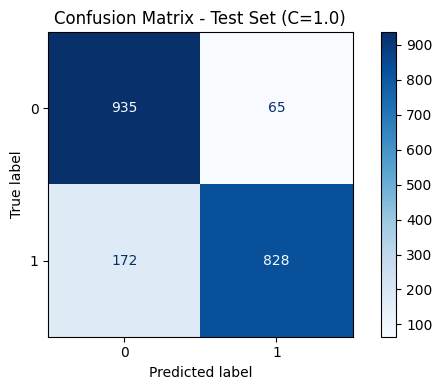

In [4]:
print(f"--- Retraining Best Configuration on Full Train Set ---")

# Initialize the optimal pipeline with the winning C value
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(C=best_c, random_state=42, dual=False, max_iter=2000))
])

# Train on the full training set
best_pipeline.fit(X_train, y_train)

# Predictions on the three splits
pred_train = best_pipeline.predict(X_train)
pred_val = best_pipeline.predict(X_val)
pred_test = best_pipeline.predict(X_test)

# Print the classification reports
print("\n=== Train Set Evaluation ===")
print(classification_report(y_train, pred_train, zero_division=0))

print("=== Validation Set Evaluation ===")
print(classification_report(y_val, pred_val, zero_division=0))

print("=== Test Set Evaluation ===")
print(classification_report(y_test, pred_test, zero_division=0))

# Confusion Matrix visualization
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)

fig_cm, ax_cm = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax_cm, cmap="Blues", xticks_rotation=0)
plt.title(f"Confusion Matrix - Test Set (C={best_c})")
plt.tight_layout()
plt.show()

### ROC and PR curve

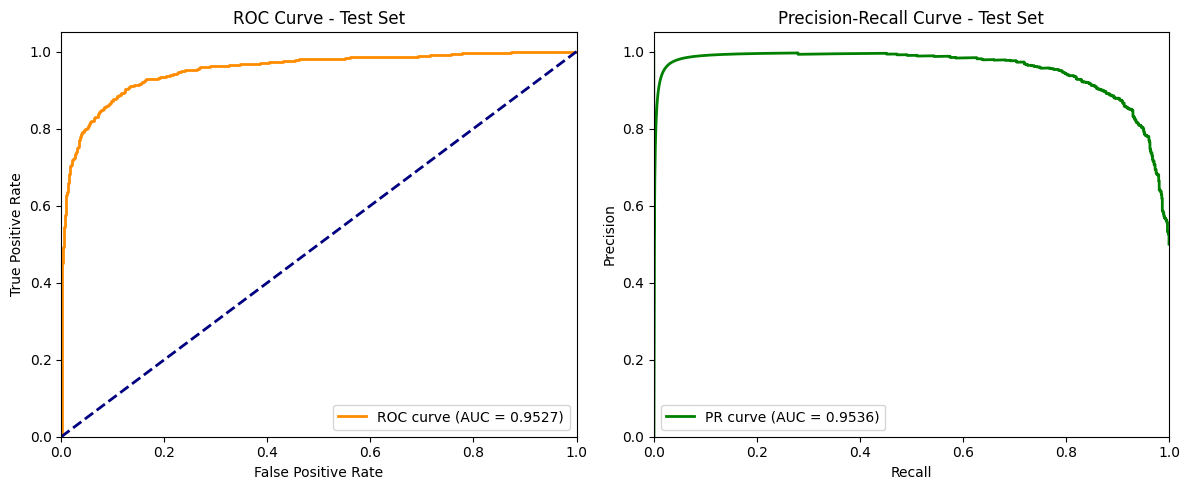

In [5]:
#Extract decision_function scores for LinearSVC (required for curves)
y_scores = best_pipeline.decision_function(X_test)

# Create a figure with two side-by-side subplots
fig_curves, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') 
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title(f'ROC Curve - Test Set')
ax1.legend(loc="lower right")

# PR Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve - Test Set')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

### Overfitting Diagnostics (Train vs Validation)

To diagnose potential overfitting, the model's performance on the Training set is compared directly against the Validation set. This is assessed by calculating the Hinge Loss (the native cost function optimized by SVM) and the Macro-F1 score for both splits. A significant gap between the training and validation metrics indicates overfitting.


--- Overfitting Analysis: Training vs Validation ---


,Metric,Training,Validation,Gap (Val - Train),Gap (Train - Val)
0,Hinge Loss (Lower is better),0.1166,0.1283,0.0117,NaN
1,Macro-F1 (Higher is better),0.9660,0.9575,NaN,0.0085



--- Interpretation ---
Good: The gap between Training and Validation scores is minimal.
The model generalizes well and does not show severe signs of overfitting.



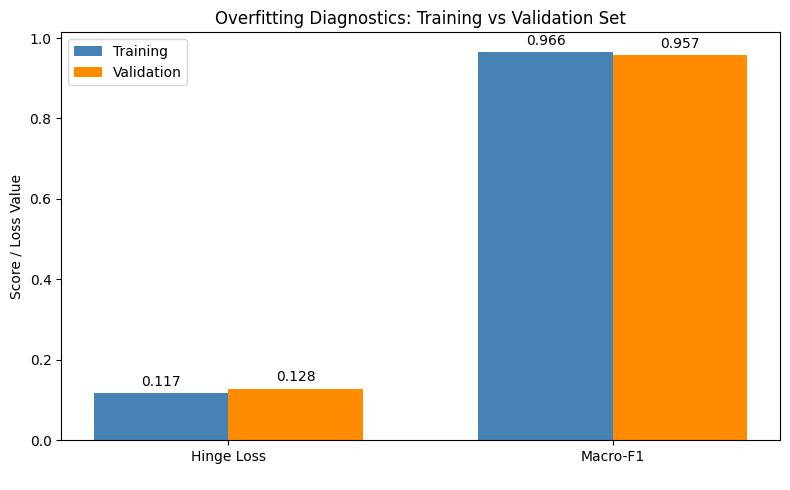

In [6]:
print("\n--- Overfitting Analysis: Training vs Validation ---")

# Extract the decision function scores using the pre-processed feature matrices
dec_train = best_pipeline.decision_function(X_train)
dec_val = best_pipeline.decision_function(X_val)

# Hinge loss requires numeric targets {-1, 1}
# The classes are dynamically mapped based on the pipeline's detected classes
positive_class = best_pipeline.classes_[1]
y_train_num = np.where(y_train == positive_class, 1, -1)
y_val_num = np.where(y_val == positive_class, 1, -1)

# Calculate Hinge Loss
loss_train = hinge_loss(y_train_num, dec_train)
loss_val = hinge_loss(y_val_num, dec_val)

# Calculate Macro-F1 Score
f1_train = f1_score(y_train, pred_train, average='macro')
f1_val = f1_score(y_val, pred_val, average='macro')

# Calculate the gap between sets
loss_gap = loss_val - loss_train
f1_gap = f1_train - f1_val

# Structure the results in a DataFrame for clean visualization
overfitting_data = [
    {"Metric": "Hinge Loss (Lower is better)", "Training": loss_train, "Validation": loss_val, "Gap (Val - Train)": loss_gap},
    {"Metric": "Macro-F1 (Higher is better)", "Training": f1_train, "Validation": f1_val, "Gap (Train - Val)": f1_gap}
]

df_overfitting = pd.DataFrame(overfitting_data)

# Round numeric columns for better readability
df_overfitting = df_overfitting.round(4)

# Display the formatted table
display(df_overfitting)

# Provide an automated interpretation based on the F1 Gap
print("\n--- Interpretation ---")
if f1_gap > 0.15:
    print("Warning: A significant gap between Training and Validation scores is detected (F1 Gap > 0.15).")
    print("This suggests the model might be overfitting the training data.")
elif f1_gap < -0.05:
    print("Notice: Validation score is notably higher than Training score. Check data distribution.")
else:
    print("Good: The gap between Training and Validation scores is minimal.")
    print("The model generalizes well and does not show severe signs of overfitting.\n")

# Graphical Visualization (Bar Chart)
metrics = ['Hinge Loss\n', 'Macro-F1\n']
train_scores = [loss_train, f1_train]
val_scores = [loss_val, f1_val]

x = np.arange(len(metrics)) 
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, train_scores, width, label='Training', color='steelblue')
rects2 = ax.bar(x + width/2, val_scores, width, label='Validation', color='darkorange')

ax.set_ylabel('Score / Loss Value')
ax.set_title('Overfitting Diagnostics: Training vs Validation Set')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()

### Most uncertain documents
This section identifies the 5 documents from the Test set where the classifier exhibited the highest uncertainty. In the context of a Linear SVM, uncertainty is quantified by the absolute value of the `decision_function`, which represents the signed distance of a sample to the separating hyperplane. Values closest to zero indicate points that lie nearly on the decision boundary, making them the most difficult instances for the model to classify. The results are presented in a table detailing their true and predicted labels, alongside a text snippet for qualitative error analysis.

In [7]:
print("\n--- Top 5 Most Uncertain Documents in Test Set ---")

distances = np.abs(best_pipeline.decision_function(X_test))

# Get the indices of the 5 documents with the smallest distance
uncertain_indices = np.argsort(distances)[:5]

# Collect the data in a list of dictionaries
uncertain_data = []
for i, idx in enumerate(uncertain_indices):
    uncertain_data.append({
        "Rank": i + 1,
        "Original_Index": idx,
        "Distance": round(distances[idx], 6),
        "True_Label": df_test['label'].iloc[idx],
        "Predicted_Label": pred_test[idx],
        "Text_Snippet": df_test['text'].iloc[idx][:150] + "..."
    })

# Convert to a Pandas DataFrame for enhanced visualization
df_uncertain = pd.DataFrame(uncertain_data)

# Display the DataFrame (renders as a formatted HTML table in Jupyter Notebooks)
display(df_uncertain)


--- Top 5 Most Uncertain Documents in Test Set ---


,Rank,Original_Index,Distance,True_Label,Predicted_Label,Text_Snippet
0,1,1480,0.000214,0,1,Secondo il quotidiano Standard le violenze pro...
1,2,409,0.002330,1,0,Uno studio recente della Harvard School of Pub...
2,3,1114,0.006488,1,1,"Un vero e proprio serpentone di persone, con a..."
3,4,1594,0.008000,1,0,"Lanciato immediatamente l'allarme, sul posto s..."
4,5,896,0.008919,0,0,"Servirà il 3-0 o il 4-1. Tutto in salita, quin..."


### Top 20 most relevant features
In this section the top 20 most discriminant non-lexical features are extracted and analyzed. In a linear SVM, the relevance of each feature is directly proportional to the absolute value of its corresponding weight in the model's coefficient array (`coef_`). Features with the highest absolute coefficients exert the greatest influence on the positioning of the decision boundary. The following analysis isolates these top features, presenting them alongside a bar chart to facilitate a deeper linguistic interpretation of the structural and syntactic metrics that most effectively differentiate human from machine-generated texts.

--- Top 20 Most Relevant Features ---
                  Feature  Importance
                 n_tokens    3.084379
   n_prepositional_chains    2.045764
          upos_dist_PUNCT    1.858292
             dep_dist_det    1.684660
            upos_dist_DET    1.596626
      ttr_form_chunks_200    1.385363
           dep_dist_punct    1.333805
          dep_dist_advmod    1.147981
           upos_dist_PRON    1.140248
          lexical_density    1.112308
            upos_dist_NUM    0.938149
            upos_dist_ADV    0.799547
avg_subordinate_chain_len    0.758612
    dep_dist_flat:foreign    0.743100
            dep_dist_amod    0.730732
          upos_dist_PROPN    0.725661
       dep_dist_acl:relcl    0.714151
           upos_dist_VERB    0.695653
          tokens_per_sent    0.653780
     ttr_lemma_chunks_200    0.620043


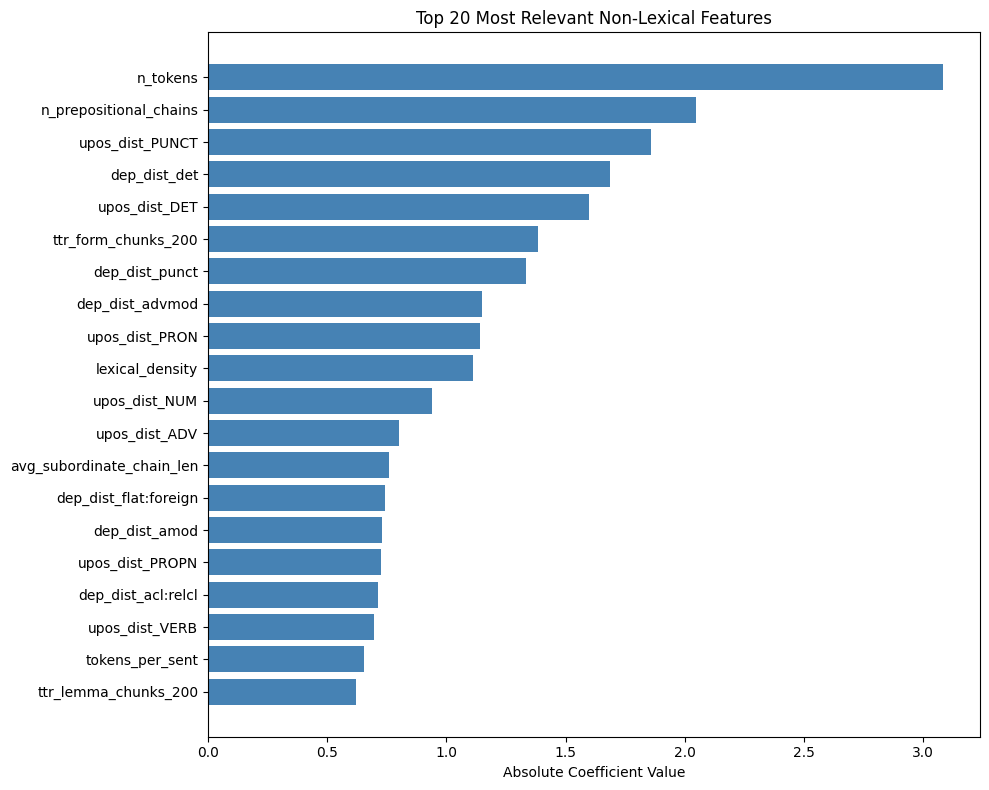

In [8]:
print("--- Top 20 Most Relevant Features ---")
# Extract the trained LinearSVC model from the pipeline
trained_svc = best_pipeline.named_steps["clf"]

# Extract feature names from the DataFrame
feature_names = X_train.columns

# The relevance of a feature in a linear SVM is given by the absolute value of its coefficient
feature_importances = np.abs(trained_svc.coef_[0])

# Create a DataFrame to store and sort the features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

top_20_features = importance_df.head(20)

# Print the top 20 features
print(top_20_features.to_string(index=False))

# Plot the top 20 features for better visualization
plt.figure(figsize=(10, 8))
# Slicing with [::-1] to plot the most important at the top of the horizontal bar chart
plt.barh(top_20_features['Feature'][::-1], top_20_features['Importance'][::-1], color='steelblue')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Most Relevant Non-Lexical Features')
plt.tight_layout()
plt.show()